<a href="https://colab.research.google.com/github/alexiatak/astrostat/blob/main/BAYES/Bayesian_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Introduction to Bayesian Statistics

The key idea behind Bayesian statistics requires a complete change of perspective regarding the way we approach problems. In a (probably far-fetched) analogy with physics, it would be similar to how we perceive gravity in a Newtonian versus a General Relativistic universe. In this notebook we will discuss:

- Bayes' theorem
- The main Bayesian components: prior, likelihood, posterior, and evidence
- Using Bayesian statistics for parameter estimation
- Marginalization over nuissance parameters (and the difference with conditioning)

# Setup

In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
import requests
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

Repository:
https://github.com/AstroStat-Academy/astrostat-school-7.git

Branch:
main

Working in:
/content/astrostat-school-7/Bayesian

Content:
	 ['Bayesian_1.ipynb', 'Bayesian_2.ipynb', 'images']
Imported matplotlib.
Imported seaborn.
Plotting style set.


  # The problem: Counting photons...

  An X-ray imaging observation hands us a list of <span style="color:#d87c3a">**events**</span>: for each photon the telescope detects, we record its <span style="color:#d87c3a">**position and
  energy**</span>. Since we are literally counting photons, we call them <span style="color:#d87c3a">**counts**</span>, and the <span style="color:#d87c3a">**count rate**</span> is just the number
  of counts per second. The <span style="color:#d87c3a">*count rate scales with the flux*</span> of the source in the telescope's energy band.


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/Bayesian/images/NGC1482_opt.jpg?raw=1" width="48%" style="display:inline-block;">
<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/Bayesian/images/NGC1482.png?raw=1" width="48%" style="display:inline-block;">

<table><tr><td width=800><center><br>
    Figure 1. <i>Left -</i> Some galaxy seen in optical wavelengths. <i> Right -</i> The same galaxy observed in X-rays. Each dot represents a photon that has been detected. The energy of the photon is known as well (not shown). The ellipse defines the extent of the source based on the image in the optical.
<br></center></td></tr></table>

  <span style="color:#d87c3a">**Source-detection algorithms**</span> group the events into <span style="color:#d87c3a">**source regions**</span> — one list of photons per source. From there, a chain
  of modeling steps turns those photons into the physical quantity we actually care about:

  - The *integrated energy* of a source region estimates the *energy collected by the telescope* — once the detector response and absorption are accounted for.
  - With *enough counts*, we can *fit the source's spectrum*.
  - Modeling the detector, the intergalactic absorption, and the spectrum gives the <span style="color:#d87c3a">*bolometric* flux</span> — the flux a perfect experiment would measure.
  - Finally, given the source's distance, flux converts to <span style="color:#d87c3a">luminosity</span>. This an intrinsic property of the source, which is usually what we're after.


## How many counts are we going to get?

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: If each photon count during the exposure (e.g., 50 ks) corresponds to luminosity $10^{38}\,\rm erg\,s^{-1}$, and our source emits $5\times 10^{38}\,\rm erg\,s^{-1}$, what is **on average** the number of counts we will measure?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

We can get an estimate of the photon counts by simply dividing.
    
</details>
</div>


In [ ]:
COUNT_TO_LUMINOSITY = 1.0e38  # in erg/s
source_luminosity = 5.0e38    # in erg/s
expected_counts = source_luminosity / COUNT_TO_LUMINOSITY
print(f"Expected counts: {expected_counts:.3f}")

Expected counts: 5.000


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: What is the distribution of the potential multiple count measurements?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

This is a counting problem. We expect each measurement of a photon to be independent of the others, so... it's Poisson!

$$ P(\textrm{counts} | \textrm{expected}) = P(k | \lambda) = \textrm{Pois}(k; \lambda) = \dfrac{\lambda^k e^{-\lambda}}{k!} $$

**Reminder**: The *Poisson distribution* is a discrete probability distribution that expresses the probability of a given number of events occurring in a fixed interval of time, if these events occur with a known constant mean rate and independently of the time since the last event.
   
</details>
</div>


Let's plot a Poisson distribution.

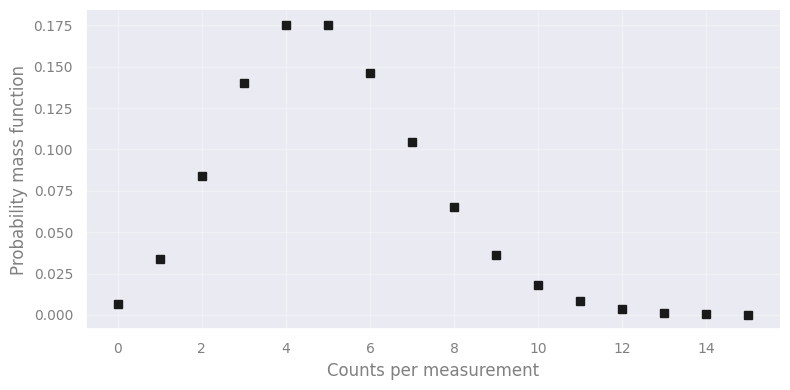

In [ ]:
outcomes = np.arange(0, int(expected_counts*3)+1, 1)
pmf = st.poisson(expected_counts).pmf(outcomes)
plt.figure()
plt.plot(outcomes, pmf, "ks")
plt.xlabel("Counts per measurement")
plt.ylabel("Probability mass function")
plt.show()

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: What is the uncertainty on the measured counts?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

Since it's Poisson, the standard deviation is the square root of the expected value!
   
</details>
</div>


Let's compute the uncertainty on the measured counts. We can either use a formula or a `scipy` function.

In [ ]:
counts_uncertainty = expected_counts**0.5
print(f"Uncertainty: {counts_uncertainty:.3f}")

Uncertainty: 2.236


## Estimating the luminosity of a source


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: Let's do the opposite now. We found a source that emitted 5 counts. What is the luminosity of the source?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

The Poisson distribution above peaks both at 5 and 4 counts.
If we got 4 counts, would $5\times 10^{38}\,\rm erg\,s^{-1}$ still be a good answer for the expected luminosity of the source?
There is something weird going on!
We have one measurement and we ask a question about the source.
Also, we are always going to get integer multiples of the count/luminosty factor this way.
But nature doesn't care about how many photons we measured, how far away we are from the source, etc.   
</details>
</div>



<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 1: Select three offsets (can be negative, positive, or zero) around the mean value and inspect the resulting distributions. What do you notice?

</div>

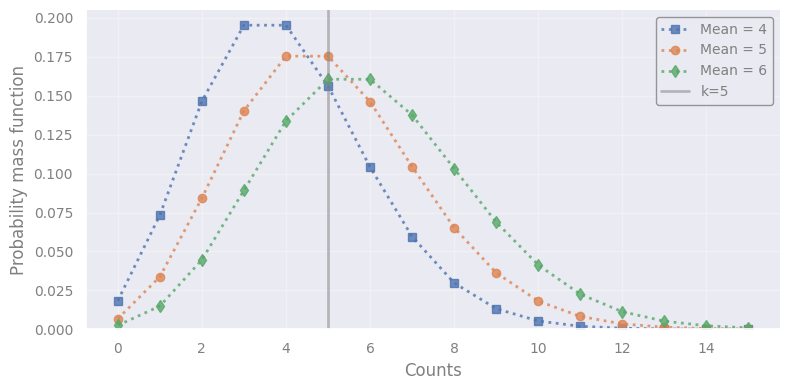

In [ ]:
outcomes = np.arange(0, int(expected_counts*3)+1, 1)
plt.figure()
# try different offsets around the expected mean value and plot the PMF
for offset, marker in zip([-1.0,0.0,1.0], ["s", "o", "d"]):
    mean = expected_counts + offset
    plt.plot(outcomes, st.poisson(mean).pmf(outcomes), ":", marker=marker, alpha=0.8, label=f"Mean = {mean:.4g}")
plt.axvline(expected_counts, color="0.5", alpha=0.5, label="k=5")
plt.ylim(ymin=0)
plt.legend(loc="upper right")
plt.xlabel("Counts")
plt.ylabel("Probability mass function")
plt.show()

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

<pre>
for offset, marker in zip([-0.5, 0.0, 0.3], ["s", "o", "d"]):
</pre>
  
</details>
</div>

### We have multiple (actually infinite) hypotheses for the source luminosity

Before, we had the **source luminosity fixed**, and we wondered what we would measure if we repeated the experiment many times.
This is the <span style="color:#d87c3a">**frequentist approach**</span>.
We also assigned some uncertainty to the data.

> **A frequentist assigns probabilities to data - parameters are fixed. The probability is a *frequency* of data outcomes.**

But when asking about the nature of things (as is the case in all applied sciences), we are not interested in assigning uncertainty to the data.
The data are what they are, and in some cases they may be fundamentally unique, e.g. because some experiments cannot be repeated.
We need to *assign probabilities to the quantity of interest*.
This is the <span style="color:#d87c3a">**Bayesian approach**</span>:

$$ \Large P(\textrm{hypothesis} | \textrm{data}) $$

> **A Bayesian assigns probabilities to hypotheses. The probability is a *degree of belief* in a value of a parameter.**


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/Bayesian/images/Sivia_Logic.png?raw=1" width="600" style="display:block; margin-left:auto; margin-right:auto;"/>

<table><tr><td width=700><center><br>
    Figure 2. A schematic representation of (a) deductive logic or pure mathematics, and (b) inductive logic or plausible reasoning.
<br></center></td></tr></table>


# Bayes Theorem: The Foundation of Bayesian Inference

To navigate from what we can model, $P(\textrm{data} | \textrm{hypothesis})$, to what we want to know, $P(\textrm{hypothesis} | \textrm{data})$, we use **Bayes Theorem** that arises from the basic rules of probability.

The joint probability of two events (or propositions) A and B occurring, $P(A, B)$, can be written in two ways:

$$ \Large P(A, B) = P(A | B) P(B) $$

$$ \Large P(A, B) = P(B | A) P(A) $$

Since $P(A,B)$ is the same in both expressions, we can equate them:

$$ \Large P(A | B) P(B) = P(B | A) P(A) $$

Rearranging this gives us Bayes Theorem:

$$ \Large P(A | B) = \dfrac{P(B | A) P(A)}{P(B)} $$

In the context of data and hypotheses, we write this as:

$$ \Large P(\textrm{hypothesis} | \textrm{data}, I) = \dfrac{P(\textrm{data} | \textrm{hypothesis}, I) P(\textrm{hypothesis} | I)}{P(\textrm{data} | I)} $$

Here, $I$ represents *all our background information and assumptions*.


We made everything conditional to $I$, the **background information**: all relevant knowledge we have about the problem we are solving but are not part of the data or the specific hypothesis being tested.

For example, if we are testing whether a die is fair, the data are a sequence of outcomes (e.g., 1, 6, 3, 5, 3, 1), the hypothesis could be **the probability of rolling a 6 is $p_6=1/6$**, and $I$ = $\big\{$ all dice have 6 sides and are cubes, a fair die has equiprobable sides, the laws of physics as we know them, $\cdots \big\}$.

For brevity, **we usually omit writing the $I$** in the equations, but **its always there**... somewhere in the background!

All the terms of Bayes Theorem have specific names:

*   <span style="color:#d87c3a">**Prior Probability**</span>: $P(\text{hypothesis} | I)$ is the degree of belief in the hypothesis *before* looking at the current data. It encapsulates our previous knowledge, physical constraints, or initial assumptions. For example it can just be a range.
*   <span style="color:#d87c3a">**Likelihood**</span>: $P(\text{data | hypothesis}, I)$ is the probability of observing the data *given* that the hypothesis is true. This is what we often model based on our understanding of the data generation process.
*   <span style="color:#d87c3a">**Posterior Probability**</span>: $P(\text{hypothesis} | \text{data}, I)$ is the (updated) degree of belief in the hypothesis *after* considering the data.
*   <span style="color:#d87c3a">**Evidence (or Marginal Likelihood)**</span>: $P(\text{data} | I)$ is the overall probability of observing the data, averaged over all possible hypotheses.

> In Bayesian Analysis we assign degrees of belief to hypotheses (prior), which we "update" using experimental data (via the likelihood), to arrive at a new, refined degree of belief in the hypotheses (posterior).


# A Deeper Look at the Components:


## Priors $P(\text{hypothesis} | I)$
The <span style="color:#d87c3a">prior</span> represents our state of knowledge about the hypothesis *before we consider the current dataset*. It can come from previous experiments, theoretical predictions, or fundamental principles. The choice of prior can be influential, especially with limited data, and is a key aspect of Bayesian modeling.

Priors can be broadly categorized as **informative** or **uninformative** or, more accurately, **weakly informative**.

*   <span style="color:#d87c3a">**Informative Priors**</span>: These reflect specific, <span style="color:#d87c3a">existing information</span> about the parameter before observing the current data. This information might come from previous experiments, physical laws, or established theories. For example, if measuring the mass of a planet, an informative prior might restrict the mass to be positive and perhaps within a range plausible for planets.

*   <span style="color:#d87c3a">**Uninformative/Weakly Informative Priors**</span>: These are intended to <span style="color:#d87c3a">let the data speak for themselves</span> as much as possible, or to represent a state of relative ignorance. However, a truly "uninformative" prior is often elusive. The most common approach is to use **uniform priors**. Those assign equal probability to all possible values of a parameter within a given range. For a parameter $\theta$ bounded by $\theta_{min}$ and $\theta_{max}$, $P(\theta|I) \propto 1$.


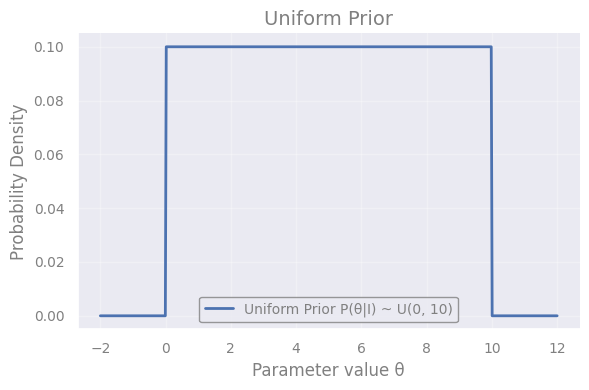

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(6, 4))

# Uniform Prior
x_uniform = np.linspace(-2, 12, 500)
pdf_uniform = st.uniform(loc=0, scale=10).pdf(x_uniform) # Uniform between 0 and 10
axs.plot(x_uniform, pdf_uniform, label='Uniform Prior P(θ|I) ~ U(0, 10)')
axs.set_title('Uniform Prior')
axs.set_xlabel('Parameter value θ')
axs.set_ylabel('Probability Density')
axs.legend()
plt.show()

> The choice of prior should always be justified and its impact on the results assessed, especially if strong claims are made from weakly informative data.


## Likelihood $P(\text{data} | \text{hypothesis}, I)$

The <span style="color:#d87c3a">likelihood</span> is what <span style="color:#d87c3a">connects the data to the parameters</span>: it tells us how probable the observed data are for a given value of the parameters. The choice of likelihood states our assumptions about how the data were generated, what process produced them, and what kind of noise they carry. Its form follows from the *nature of the data*: continuous measurements, discrete counts, binary outcomes, and so on. Each of these processes corresponds to a different distribution.

Two cases cover most of what we meet in practice:

**Gaussian (Normal) likelihood** — for <span style="color:#d87c3a">continuous data</span> scattered symmetrically around a mean, e.g. a brightness measurement with normally-distributed noise. For $N$ points $x_i$ drawn from a Gaussian with mean $\mu$ and standard deviation $\sigma$:

$$ \Large P(\{x_i\} | \mu, \sigma, I) = \prod_{i=1}^N \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right) $$

**Poisson likelihood** — for <span style="color:#d87c3a">count data</span>: independent events at a constant mean rate, e.g. the number of X-ray photons $k$ detected when the expected count is $\lambda$ (this is our running example).

$$ \Large P(k | \lambda, I) = \frac{\lambda^k e^{-\lambda}}{k!} $$

When none of the standard distributions is appropriate, the likelihood is <span style="color:#d87c3a">built from a model of the measurement itself</span>. This can be derived from the instrument's physics, combined from several noise sources, or, when no closed form exists, evaluated numerically by simulating the data-generating process.

Two things are worth keeping in mind:

1. Although the likelihood is a probability distribution *over the data*, we read it as a function of the **parameters** at the **fixed, observed data**. In a true *Bayesian* way, this informs us about the hypothesis.

2. It is a *modeling choice*: if its assumptions are badly violated, the inference can mislead, which is why heavier-tailed alternatives (e.g. a Student's-$t$ in place of a Gaussian) are sometimes used to blunt the effect of outliers.

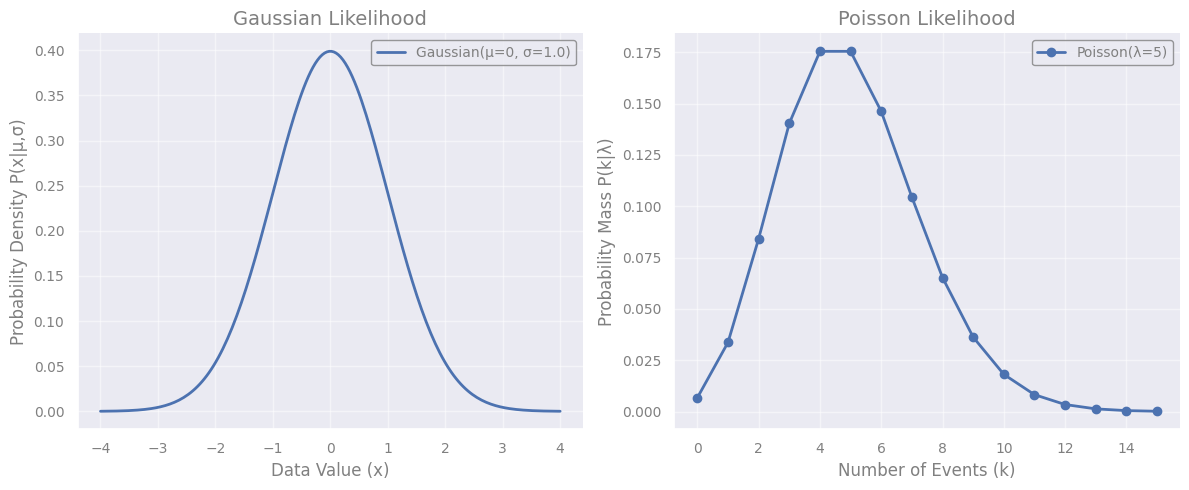

In [ ]:
# Example Plots of Common Likelihood Functions
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs = axs.ravel() # Flatten the 1x2 array of axes for easy iteration

# 1. Gaussian Likelihood
mu_g, sigma_g = 0, 1.0 # Example parameters: mean, std_dev
x_g = np.linspace(mu_g - 4*sigma_g, mu_g + 4*sigma_g, 200)
pdf_g = st.norm.pdf(x_g, loc=mu_g, scale=sigma_g)
axs[0].plot(x_g, pdf_g, label=f'Gaussian(μ={mu_g}, σ={sigma_g})')
axs[0].set_title('Gaussian Likelihood')
axs[0].set_xlabel('Data Value (x)')
axs[0].set_ylabel('Probability Density P(x|μ,σ)')
axs[0].legend()
axs[0].grid(True, alpha=0.5)

# 2. Poisson Likelihood
lambda_p = 5 # Example parameter: expected rate λ
k_p = np.arange(0, lambda_p * 3 + 1)
pmf_p = st.poisson.pmf(k_p, mu=lambda_p)
axs[1].plot(k_p, pmf_p, 'o-', label=f'Poisson(λ={lambda_p})')
axs[1].set_title('Poisson Likelihood')
axs[1].set_xlabel('Number of Events (k)')
axs[1].set_ylabel('Probability Mass P(k|λ)')
axs[1].legend()
axs[1].grid(True, alpha=0.5)


plt.tight_layout()
plt.show()

## The Evidence $P(\text{data} | I)$:
The evidence is the probability of the data, averaged over all possible values of the hypothesis parameters, weighted by their prior probabilities. If $\theta$ represents the parameters of our hypothesis, then:

$$ \Large P(\text{data} | I) = \int P(\text{data} | \theta, I) P(\theta | I) d\theta $$

In parameter estimation problems (where we are trying to find the best values of $\theta$), the evidence $P(\text{data} | I)$ is a constant for a given dataset and choice of model. It ensures that the posterior probability distribution is properly normalized (i.e., integrates/sums to 1). While it often cancels out or is <span style="color:#d87c3a">ignored in parameter estimation</span> as we often care about $P(\text{hypothesis} | \text{data}) \propto P(\text{data} | \text{hypothesis}) P(\text{hypothesis})$, the evidence is <span style="color:#d87c3a">**crucial for model comparison**</span>, a topic we will explore later. It allows us to compare how well different models (different forms of hypotheses or priors) can explain the data.


# Back to our counting experiment: what does Bayes say about it...

$$ \Large P(\text{hypothesis} | \text{data}) = P(\lambda | k) \propto P(k | \lambda) P(\lambda) $$

where in this case, since we care only for the value of the parameters, we can ignore the evidence term (which is just a normalization constant).

## Assigning a prior

We need to choose a prior $P(\lambda | I)$ that describes our belief on the source luminosity and, more specifically, its expected counts, $\lambda$.


**Option 1: Uniform Prior over a finite range (Principle of Indifference)**

We may have a constraint, e.g. for galaxies that contain an Active Galactic Nucleus $\lambda$ is above 20, but we know from other measurements that this is not the case for our galaxy (this is background information $I$):

$$ \Large P(\lambda | I) = \begin{cases} C , & 0\leq \lambda < 20 \\ 0 , & \text{elsewhere} \end{cases}$$

The constant $C$ would be $1/20$ in order to normalize the prior. However, for parameter inference we are actually interested in the shape of the posterior $P(\lambda | k) \propto P(k | \lambda) P(\lambda)$, thus we can often ignore normalization constants.


**Option 2: Uniform (Improper) Prior for $\lambda \ge 0$ (Agnostic approach)**

Maybe we have no other information and want to be **agnostic** about $\lambda$ (other than it must be non-negative):

$$  \Large P(\lambda | I) = \text{const.}, \quad \lambda \ge 0 $$

This is an **improper prior** because its integral over $[0, \infty)$ diverges. However, it can still lead to a proper posterior. Since it is just a constant, it does not affect the posterior shape.


## Assigning a likelihood

We can use the Poisson likelihood, just like in the frequentist approach:

$$ \Large P(k | \lambda) = \dfrac{\lambda^k e^{-\lambda}}{k!} $$


## What is the Posterior?

In the case of a proper prior we get:

$$ \Large P(\lambda | k) \propto P(k | \lambda) P(\lambda) \propto \begin{cases} \dfrac{\lambda^k e^{-\lambda}}{k!} , & 0\leq \lambda < 20 \\ 0 , & \text{elsewhere} \end{cases}$$

while for an improper one the posterior is:

$$ \Large P(\lambda | k) \propto P(k | \lambda) P(\lambda) \propto P(k | \lambda) \propto \dfrac{\lambda^k e^{-\lambda}}{k!} \quad \text{for } \lambda \ge 0$$

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">
<b>In-class discussion: Are we back to frequentism when using uniform priors?</b>
<br>
<i>Discuss with your teammate, then report.</i>
</div>

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">

<details>

<b><summary>[Spoiler] (click here to expand)</summary></b>

No! Bayesian inference is not just frequentism + priors. Even if the formula for the posterior $P(\lambda|k)$ looks proportional to the likelihood $P(k|\lambda)$ when using a flat prior, the interpretation is fundamentally different.

The posterior $P(\lambda|k)$ is a probability distribution for the parameter $\lambda$, given the observed data $k$. The likelihood $P(k|\lambda)$ is a probability distribution for the data $k$, given a fixed parameter $\lambda$.

The posterior $P(\lambda | k) \propto \lambda^k e^{-\lambda}$ (for $k$ fixed, $\lambda \ge 0$) is a probability density function of the continuous quantity $\lambda$. In fact, it is a Gamma distribution: specifically, $\text{Gamma}(\text{shape}=k+1, \text{scale}=1)$ or $\text{Gamma}(\alpha=k+1, \beta=1)$ depending on parameterization (e.g., if PDF is $f(x;\alpha,\beta) = \frac{\beta^\alpha x^{\alpha-1}e^{-\beta x}}{\Gamma(\alpha)}$).

As a consequence, Maximum Likelihood Estimation (see previous lecture) is rooted in the frequentist idea of how often data like ours would be observed if a parameter had a certain value. Bayesian inference provides a probabilistic statement about the parameter itself, given the observed data and prior beliefs.   
</details>
</div>



<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 2: Compute the posterior values for the trial $\lambda$ values. What is the best-fitting value for $\lambda$?

</div>

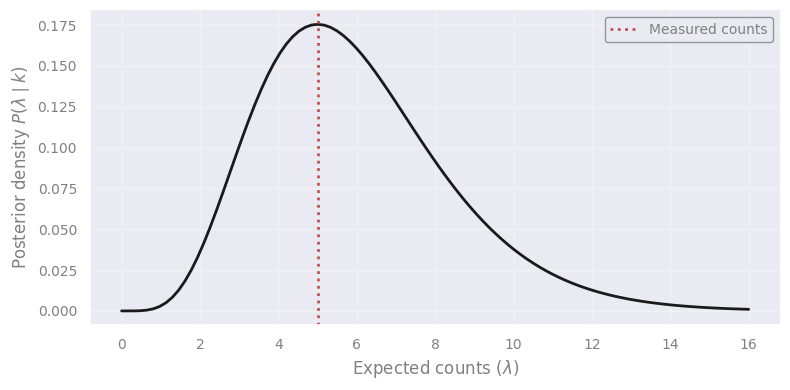

In [ ]:
measure_counts = 5.0
lambda_values = np.linspace(0, int(measure_counts*3)+1, 100)
posteriors = st.gamma(a=measure_counts+1,scale=1).pdf(lambda_values)
#u can change the pdf to cdf to see a diff distrubution
plt.figure()
plt.plot(lambda_values, posteriors, "k-")
plt.xlabel(r"Expected counts ($\lambda$)")
plt.ylabel(r"Posterior density $P(\lambda \mid k)$")
plt.axvline(5.0, color="r", ls=":", label="Measured counts")
plt.legend(loc="upper right")
plt.show()

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

Using a uniform prior means that the posterior is $P(\lambda | k) \propto \lambda^k e^{-\lambda}$, which for k counts is exactly the Gamma(k+1, scale=1) probability density function over the rate $\lambda$.
    
<pre>
posteriors = st.gamma(a=measure_counts + 1, scale=1).pdf(lambda_values)
</pre>
  
</details>
</div>

# Parameter Marginalization: Focusing on What Matters

Often, our statistical models involve multiple parameters. However, we might only be interested in a subset of these parameters, while the others are necessary for a complete model but not of direct interest. These latter parameters are often called **nuisance parameters**.

For example, when measuring the flux, $\mu$, of a star, the noise level or background uncertainty, $\sigma$, in our measurements might also be an unknown parameter that we need to account for in our model. While we need to estimate $\sigma$ to properly assess $\mu$, our primary goal is the value of $\mu$, making $\sigma$ a nuisance parameter in this context.

Bayesian inference provides a natural and powerful way to deal with nuisance parameters through **marginalization**. If we have a joint posterior probability distribution for all parameters, say $P(\theta_1, \theta_2, ..., \theta_k | \text{data}, I)$, and we are only interested in a specific parameter (or subset of parameters) $\theta_1$, we can obtain its marginal posterior probability distribution by integrating (or summing, for discrete parameters) the joint posterior over all other nuisance parameters ($\theta_2, ..., \theta_k$):

$$ \Large P(\theta_1 | \text{data}, I) = \int \dots \int P(\theta_1, \theta_2, \dots, \theta_k | \text{data}, I) \, d\theta_2 \dots d\theta_k $$

For a two-parameter case (e.g., $\mu$ and $\sigma$):

$$ \Large P(\mu | \text{data}, I) = \int P(\mu, \sigma | \text{data}, I) \, d\sigma $$

The result, $P(\theta_1 | \text{data}, I)$, is the posterior probability distribution for $\theta_1$ alone, fully accounting for the uncertainty in the nuisance parameters. This means that our inferences about $\theta_1$ (like its credible interval) have properly incorporated the fact that the other parameters were not known precisely.

This is a significant advantage of the Bayesian framework. It allows us to propagate uncertainty from all parts of our model into the final inference for the quantities we care about. In frequentist statistics, dealing with nuisance parameters can sometimes be more complex, often involving techniques like profiling the likelihood or using specific test statistics designed to be insensitive to them.


<img src="https://github.com/AstroStat-Academy/astrostat-school-7/blob/main/Bayesian/images/marginalization_conditioning_example.png?raw=1" width="600" style="display:block; margin-left:auto; margin-right:auto;"/>

<table><tr><td width=700><center><br>
    Figure 3. Difference between marginalization and conditioning. The starting point is the joint (two-dimensional in this case) probability distribution shown in the middle panel. Marginalization (top) performs the integral over a set (of usually nuissance) parameters. Conditioning (bottom) assumes a fixed value of a set of parameters, essentially ``cutting'' the posterior surface with a plane in the N-dimensional parameter space - in this two-dimensional case this plane corresponds to the horizontal dashed black line in the middle panel. The vertical dashed organe and blue lines are there simply to guide the eye.
<br></center></td></tr></table>

## Example: Estimating Stellar Flux with Background as a Nuisance Parameter

Let’s apply marginalization in a practical setting.

Suppose we observe a noisy measurement of the total brightness from a patch of sky. This total brightness includes contributions from:

* The **flux** $F$ of a star (our parameter of interest),
* The **background** $B$ from surrounding light or instrumental effects (a nuisance parameter), and
* **Gaussian noise** with known standard deviation $\sigma$.

We model the observed value $x$ as:

$$ \Large x \sim \mathcal{N}(F + B, \sigma^2), $$

which means that we should detect a value fluctuating around a mean (flux + background) due to the random noise.

We will place a **broad prior** on $F$, reflecting that the star could be relatively bright or dim, and a **more informative prior** on $B$, reflecting prior knowledge about typical background levels:

$$ \Large P(F \mid I) \sim \mathcal{N}(F; \mu_F=10.0, \sigma_F=5.0) $$
$$ \Large P(B \mid I) \sim \mathcal{N}(B; \mu_B=2.0, \sigma_B=1.0) $$

Although both $F$ and $B$ are unknown, we are only interested in the posterior for $F$. To obtain it, we **marginalize over** the nuisance parameter $B$:

$$ \Large P(F \mid x) = \int P(F, B \mid x) \, dB $$

<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

<font size=4><b>Exercise 3: Define the priors, likelihood, joint posterior, and marginal posterior for $F$.

</div>

Observed value: 12.50


/tmp/ipykernel_1715/2499915414.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  posterior_vals /= np.trapz(posterior_vals, F_vals)


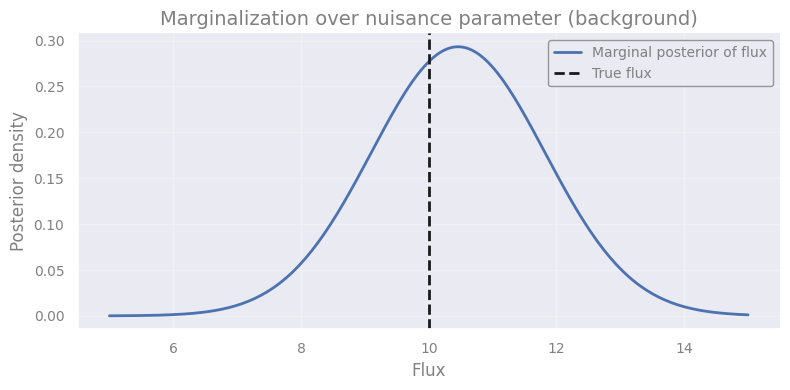

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad


# Simulated data
true_flux = 10.0
true_background = 2.0
sigma = 1.0

# One observation (flux + background + noise)
np.random.seed(42)
obs = np.random.normal(loc=true_flux + true_background, scale=sigma)

print(f"Observed value: {obs:.2f}")

# Define priors
def prior_flux(F):
    return norm.pdf(F, loc=10, scale=5)

def prior_background(B):
    return norm.pdf(B, loc=2, scale=1)

# Likelihood
def likelihood(obs, F, B):
    return norm.pdf(obs, loc=F + B, scale=sigma)

# Posterior (unnormalized, joint in F and B)
def joint_posterior(F, B):
    return likelihood(obs, F, B) * prior_flux(F) * prior_background(B)


# Marginal posterior over F (integrate out B)
def marginal_posterior_F(F):
    integrand = lambda B: joint_posterior(F, B)
    result, _ = quad(integrand, -np.inf, np.inf)  #_ is the error , we dont need it
    return result

# Evaluate marginal posterior over a grid
F_vals = np.linspace(5, 15, 200)
posterior_vals = np.array([marginal_posterior_F(F) for F in F_vals])

# Normalize
posterior_vals /= np.trapz(posterior_vals, F_vals)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(F_vals, posterior_vals, label='Marginal posterior of flux')
plt.axvline(true_flux, color='k', linestyle='--', label='True flux')
plt.xlabel('Flux')
plt.ylabel('Posterior density')
plt.legend()
plt.title('Marginalization over nuisance parameter (background)')
plt.show()

<div style="border-left: 4px solid #e57373; padding-left: 1em; padding-top: 1em; padding-bottom: 1em; margin: 1em 0; background: #fdecea; color: #1a1a1a;">
<details>

<b><summary>[Solution] (click here to expand)</summary></b>  

<pre>
# Define priors
def prior_flux(F):
    return norm.pdf(F, loc=10, scale=5)  # broad prior

def prior_background(B):
    return norm.pdf(B, loc=2, scale=1)  # informed prior

# Likelihood
def likelihood(obs, F, B):
    return norm.pdf(obs, loc=F + B, scale=sigma)

# Posterior (unnormalized, joint in F and B)
def joint_posterior(F, B):
    return likelihood(obs, F, B) * prior_flux(F) * prior_background(B)

# Marginal posterior over F (integrate out B)
def marginal_posterior_F(F):
    integrand = lambda B: joint_posterior(F, B)
    result, _ = quad(integrand, -np.inf, np.inf)
    return result
</pre>
  
</details>
</div>

In [ ]:
# EOF